
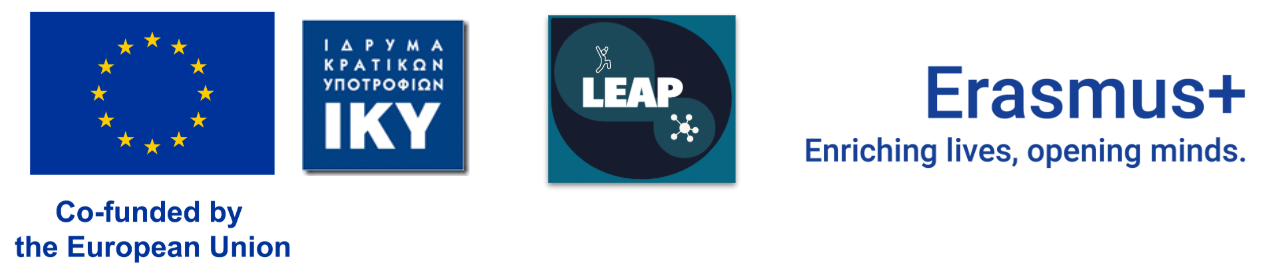

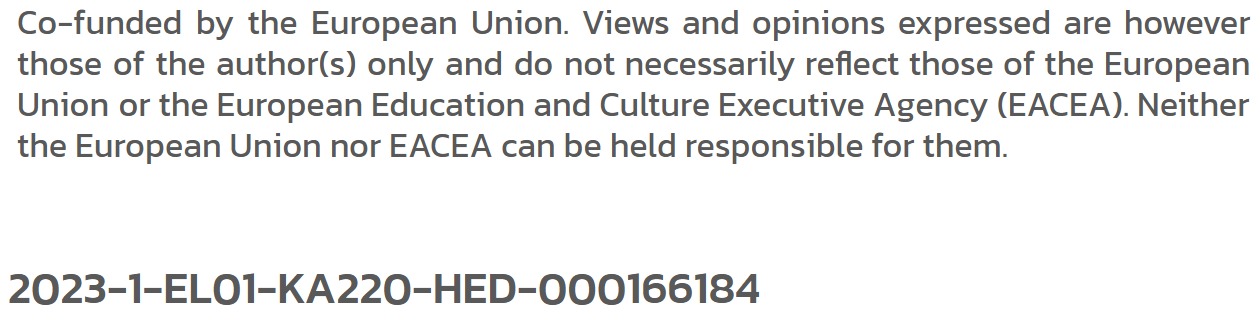

# Supervised Learning — A Classification Problem
**Full end-to-end example:** dataset creation · train/test split · preprocessing · pipeline · evaluation

The goal is not to memorise every line, but to understand the structure and why each step is necessary.

## Imports

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
)

## 1. Create the dataset

We create a synthetic tabular dataset with:
- **2 numeric features**: `age`, `income`
- **2 categorical features**: `city`, `job`
- **Missing values** introduced intentionally — just like real data

The target `y` is generated from the features using a logistic formula with added noise. This means there is a real, learnable signal — but the label is not perfectly predictable.

In [ ]:
rng = np.random.default_rng(42)
n = 600

df = pd.DataFrame({
    "age":    rng.integers(18, 70, size=n).astype(float),
    "income": rng.normal(45000, 15000, size=n).clip(5000, 120000),
    "city":   rng.choice(["Athens", "Paris", "Berlin", "Rome"], size=n, p=[0.35, 0.25, 0.25, 0.15]),
    "job":    rng.choice(["student", "engineer", "teacher", "sales"], size=n),
})

# Introduce missing values
df.loc[rng.choice(n, size=int(0.06 * n), replace=False), "age"]    = np.nan
df.loc[rng.choice(n, size=int(0.08 * n), replace=False), "income"] = np.nan
df.loc[rng.choice(n, size=int(0.04 * n), replace=False), "city"]   = np.nan

# Generate binary target from features + noise
age_f    = df["age"].fillna(df["age"].median())
income_f = df["income"].fillna(df["income"].median())
city_f   = df["city"].fillna("Unknown")
job_f    = df["job"].fillna("Unknown")

score = (
    -6.0
    + 0.06    * age_f
    + 0.00006 * income_f
    + (city_f == "Paris").astype(float)   * 0.7
    + (city_f == "Berlin").astype(float)  * 0.3
    + (job_f  == "engineer").astype(float) * 0.6
    + rng.normal(0, 0.8, size=n)
)

proba = 1 / (1 + np.exp(-score))
y = (proba >= 0.5).astype(int)
X = df.copy()

print("Dataset shape:", X.shape)
print("Positive rate (label 1):", y.mean().round(3))
print()
print(X.head())
print()
print("Missing values per column:")
print(X.isnull().sum())

Dataset shape: (600, 4)
Positive rate (label 1): 0.423

    age        income    city       job
0   NaN  40617.432213  Athens  engineer
1  58.0  43447.675979  Berlin  engineer
2  52.0  41220.339327  Berlin  engineer
3  40.0  47288.437682   Paris   teacher
4  40.0           NaN  Athens   student

Missing values per column:
age       36
income    48
city      24
job        0
dtype: int64


## 2. Train/test split

We split the data **before** any preprocessing or modelling.

- **80%** goes to training (480 people)
- **20%** is held out for testing (120 people)

`stratify=y` ensures the class balance is preserved in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)
print()
print("Positive rate — train:", y_train.mean().round(3))
print("Positive rate — test: ", y_test.mean().round(3))

Training set: (480, 4)
Test set:     (120, 4)

Positive rate — train: 0.423
Positive rate — test:  0.425


## 3. Preprocessing

Numeric and categorical columns require different treatment.

**Numeric columns** (`age`, `income`):
1. Impute missing values with the **median**
2. Standardise with **StandardScaler** (zero mean, unit variance)

**Categorical columns** (`city`, `job`):
1. Impute missing values with the **most frequent** category
2. Encode with **OneHotEncoder** (one binary column per category)

A `ColumnTransformer` applies each pipeline to the correct columns.

In [ ]:
num_cols = ["age", "income"]
cat_cols = ["city", "job"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

print("Preprocessor defined.")
print("Numeric columns :", num_cols)
print("Categorical columns:", cat_cols)

## 4. Pipeline — combining preprocessing and model

We wrap the preprocessor and the classifier into a single `Pipeline`.

This is essential for two reasons:
- **No data leakage**: the preprocessor is fitted only on training data, never on the test set
- **Clean cross-validation**: each fold fits the preprocessor independently on its own training split

In [ ]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model",      LogisticRegression(max_iter=1000)),
])

print(pipe)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'job'])

## 5. Train and evaluate on the test set

We fit the pipeline on the training data, then evaluate on the held-out test set.

Metrics:
- **Accuracy**: proportion of correct predictions
- **F1 score**: harmonic mean of precision and recall
- **Confusion matrix**: breakdown of correct and incorrect predictions by class
- **Classification report**: precision, recall, and F1 per class

In [ ]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("TEST EVALUATION")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 score:", round(f1_score(y_test, y_pred), 4))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification report:")
print(classification_report(y_test, y_pred))

TEST EVALUATION
----------------------------------------
Accuracy: 0.8417
F1 score: 0.8041

Confusion matrix:
[[62  7]
 [12 39]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        69
           1       0.85      0.76      0.80        51

    accuracy                           0.84       120
   macro avg       0.84      0.83      0.84       120
weighted avg       0.84      0.84      0.84       120



## 6. Cross-validation

A single train/test split can be sensitive to how the data was divided. Cross-validation gives a more stable estimate of performance by repeating the evaluation across multiple splits.

We use `StratifiedKFold` with 5 folds, which preserves class balance in each fold.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1")

print("CROSS-VALIDATION (F1)")
print("-" * 40)
print("Fold scores:", np.round(cv_scores, 4))
print("Mean ± Std: ", np.round(cv_scores.mean(), 4), "±", np.round(cv_scores.std(), 4))

CROSS-VALIDATION (F1)
----------------------------------------
Fold scores: [0.8172 0.8317 0.8491 0.7879 0.8462]
Mean ± Std:  0.8264 ± 0.0224
